In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/220150_tirtho_saha/Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.isnull().sum()
df = df.dropna()

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

In [ ]:
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 979679.6912959907
MSE: 1771751116594.04
R2 Score: 0.6494754192267793


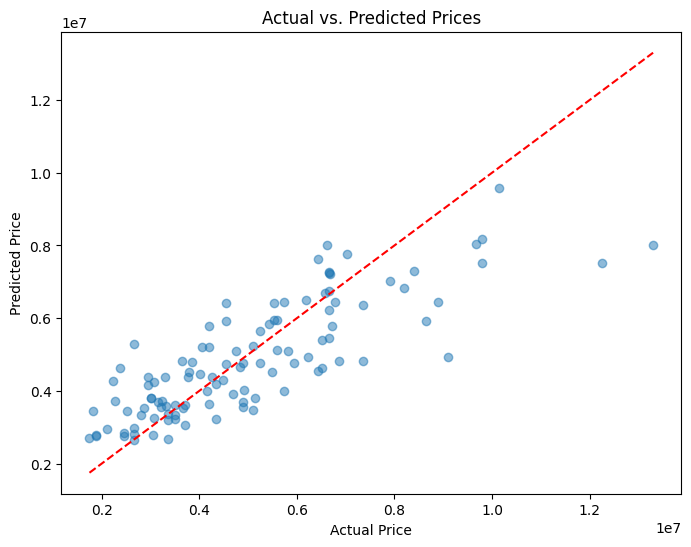

In [ ]:

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5) # alpha adds transparency to see overlapping points

# Add the 45-degree line
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Prices")
plt.show()

In [ ]:
sample = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

print(sample)

    Actual     Predicted
0  4060000  5.203692e+06
1  6650000  7.257004e+06
2  3710000  3.062829e+06
3  6440000  4.559592e+06
4  2800000  3.332932e+06
5  4900000  3.563081e+06
6  5250000  5.645466e+06
7  4543000  6.413980e+06
8  2450000  2.755832e+06
9  3353000  2.668939e+06
